# Task description

The goal is to build a simple and interpretable benchmark for the dynamics of the implied volatility surface that can serve as a baseline for comparison with more flexible generative models.

The idea is the following:
1. At each time point, we observe an implied volatility surface on a discrete grid of moneyness and time-to-expiry.
2. Since the surface is high-dimensional, it is first compressed into a small number of factors.
3. The dynamics of these factors are then modeled with a standard time-series model.
4. This benchmark can then be used to:
   - forecast future surfaces;
   - simulate realistic surface trajectories;
   - compare more complex models against a transparent baseline.

Such a benchmark is useful because it is:
- interpretable;
- fast to calibrate;
- easy to simulate from;
- suitable as a baseline for evaluating whether a more complex model delivers an actual gain.

---

## Quantitative formulation of the model

### 1. Data

Suppose that at times $t=1,\dots,T$ we observe the implied volatility surface on a fixed grid
$$
\{(M_k,\tau_m)\}_{k=1,\dots,K,\;m=1,\dots,M},
$$
where:
- $M_k$ is moneyness,
- $\tau_m$ is time to expiry.

Let
$$
\sigma_t(M_k,\tau_m)
$$
denote the observed implied volatility at grid point $(M_k,\tau_m)$.

We vectorize the surface into
$$
x_t = \mathrm{vec}\big(\log \sigma_t(M_k,\tau_m)\big)\in\mathbb{R}^{d},
\qquad d=K\cdot M.
$$

Using $\log \sigma$ is optional, but in practice it often leads to a more stable representation.

---

### 2. General factor formulation

In general form, the implied volatility surface is represented as
$$
\sigma_t(M,\tau)=f(M,\tau,Y_t),
$$
where
$$
Y_t\in\mathbb{R}^r,\qquad r\ll d
$$
is a low-dimensional factor vector, and $f$ is the reconstruction map.

On the discrete grid, this is equivalent to writing
$$
x_t \approx g(Y_t).
$$

Thus, the entire surface is assumed to be driven by a small number of latent factors.

---

### 3. Linear benchmark: PCA representation

In the benchmark version, we use a linear factor structure:
$$
x_t = \mu + W Y_t + \varepsilon_t,
$$
where
- $\mu\in\mathbb{R}^d$ is the mean surface,
- $W\in\mathbb{R}^{d\times r}$ is the loading matrix,
- $Y_t\in\mathbb{R}^r$ is the vector of factors,
- $\varepsilon_t$ is the reconstruction error.

Typically, $W$ is estimated by PCA, so its columns are the first $r$ principal components.

Then the factors are estimated as
$$
Y_t = W^\top (x_t-\mu),
$$
assuming the columns of $W$ are orthonormal.

---

### 4. Factor dynamics: VAR benchmark

The factor process is modeled in discrete time by a VAR$(p)$ model:
$$
Y_t = a + A_1Y_{t-1} + A_2Y_{t-2} + \dots + A_pY_{t-p} + u_t,
$$
where
$$
u_t\sim (0,\Sigma_u).
$$

Here:
- $a\in\mathbb{R}^r$ is the intercept,
- $A_1,\dots,A_p\in\mathbb{R}^{r\times r}$ are autoregressive coefficient matrices,
- $\Sigma_u$ is the covariance matrix of innovations.

This defines the benchmark:
**surface $\rightarrow$ PCA factors $\rightarrow$ VAR dynamics $\rightarrow$ reconstructed surface.**

---

### 5. Forecasting and simulation

#### One-step-ahead factor forecast
$$
\hat Y_{t+1|t}=a + A_1Y_t + \dots + A_pY_{t-p+1}.
$$

#### One-step-ahead surface forecast
$$
\hat x_{t+1|t}=\mu + W\hat Y_{t+1|t},
$$
and therefore
$$
\hat \sigma_{t+1|t}(M_k,\tau_m)
=
\exp\big((\hat x_{t+1|t})_{k,m}\big).
$$

#### Factor simulation
For simulated path $s$,
$$
Y_{t+1}^{(s)} = a + A_1Y_t^{(s)} + \dots + A_pY_{t-p+1}^{(s)} + u_{t+1}^{(s)},
\qquad
u_{t+1}^{(s)}\sim \mathcal N(0,\Sigma_u).
$$

#### Surface simulation
$$
x_{t+1}^{(s)}=\mu + W Y_{t+1}^{(s)},
\qquad
\sigma_{t+1}^{(s)}=\exp(x_{t+1}^{(s)}).
$$

---

## Evaluation metrics: EMD, MMD, and ACF

To evaluate the benchmark, it is useful to compare not only pointwise reconstruction errors, but also the distributional and temporal properties of the simulated trajectories. In particular, three metrics are especially relevant: Earth Mover's Distance (EMD), Maximum Mean Discrepancy (MMD), and the autocorrelation-based ACF score.

### 1. Earth Mover's Distance (EMD)

EMD measures how different two distributions are by quantifying the minimal transport cost required to transform one distribution into the other. In this project, EMD is understood as the first-order Wasserstein distance.

In the one-dimensional case, if $F_1$ and $F_2$ are two distributions with quantile functions $F_1^{-1}$ and $F_2^{-1}$, then
$$
\mathrm{EMD}(F_1,F_2)=\int_0^1 \left|F_1^{-1}(q)-F_2^{-1}(q)\right|\,dq.
$$

In other words, EMD compares quantiles of the same level under the two distributions.

In the present setting, EMD can be used to compare:
- historical and simulated distributions of factor increments;
- historical and simulated distributions of implied volatility increments at a fixed surface point.

A smaller EMD means that the simulated distribution is closer to the empirical one.

### 2. Maximum Mean Discrepancy (MMD)

MMD is a kernel-based distance between probability distributions. Its idea is to map observations into a Hilbert space and compare the mean embeddings of the two distributions there.

In general form,
$$
\mathrm{MMD}(F_1,F_2)=\left\|\mathbb{E}_{x\sim F_1}\phi(x)-\mathbb{E}_{y\sim F_2}\phi(y)\right\|^2,
$$
where $\phi(\cdot)$ is a feature map.

Using the kernel trick, this can be written as
$$
\mathrm{MMD}(F_1,F_2)
=
\mathbb{E}_{x,x'\sim F_1}k(x,x')
+
\mathbb{E}_{y,y'\sim F_2}k(y,y')
-
2\mathbb{E}_{x\sim F_1,y\sim F_2}k(x,y),
$$
where $k(\cdot,\cdot)$ is a positive-definite kernel.

A common choice is the Gaussian kernel:
$$
k(x,y)=\exp\left(-\frac{\|x-y\|^2}{\delta}\right).
$$

On finite samples $\{x_i\}_{i=1}^n$ and $\{y_j\}_{j=1}^m$, the unbiased estimator is
$$
\widehat{\mathrm{MMD}}
=
\frac{1}{n(n-1)}\sum_{i\ne j}k(x_i,x_j)
+
\frac{1}{m(m-1)}\sum_{i\ne j}k(y_i,y_j)
-
\frac{2}{mn}\sum_{i=1}^n\sum_{j=1}^m k(x_i,y_j).
$$

In this application, MMD is useful because it compares distributions in a flexible nonparametric way and is sensitive to higher-order differences, not only to mean and variance.

### 3. Autocorrelation-based ACF score

EMD and MMD compare distributions, but they do not directly measure whether the simulated trajectories reproduce the temporal dependence structure of the original data. For this reason, it is useful to include an autocorrelation-based metric.

Let $x_t$ denote the historical time series at a fixed point of the implied volatility surface, and let $x_t^{(i)}$ denote the corresponding series from the $i$-th simulated trajectory. Then the ACF score is defined as
$$
\mathrm{ACF\ score}
=
\left\|
\mathrm{ACF}(x_t,L)
-
\frac{1}{n}\sum_{i=1}^n \mathrm{ACF}\big(x_t^{(i)},L\big)
\right\|^2,
$$
where $\mathrm{ACF}(x_t,L)$ is the vector of empirical autocorrelations up to lag $L$.

This metric can be computed for:
- the level series $x_t$;
- the increment series $\Delta x_t$;
- the squared series $x_t^2$;
- the absolute value series $|x_t|$.

The ACF score measures how well the model reproduces the serial dependence structure of the data. A smaller value indicates that the simulated trajectories better match the empirical autocorrelation pattern.

## Interpretation

Taken together, these three metrics evaluate complementary aspects of model quality:
- **EMD** measures how close the simulated and empirical marginal distributions are;
- **MMD** provides a more flexible kernel-based comparison of distributions;
- **ACF score** evaluates whether the time-series dependence structure is reproduced.

Therefore, they allow the benchmark to be assessed not only in terms of static fit, but also in terms of realism of the simulated dynamics.

# Path simulation

__Technical note__

`HestonSimulator` is a class for simulating surfaces on fixed grid of log moneyness and time to maturity. Real measure coincides with risk-neutral in this implementation but generally it does not affect our experiment.

Heston model can be written as:
$$
    dS_t = S_t r dt + S_t \sqrt{v_t}dW_t^1 \\
    dv_t = \kappa(\theta - v_t)dt + \sqrt{v_t}dW_t^2 \\
    dW_t^1dW_t^2 = \rho dt
$$

Parameters for Heston model are:
- $S_0=100$
- $r=0.02$ and flat curve is assumed
- $v_0=0.1$
- $\kappa=1.5$
- $\theta = 0.04$
- $\sigma=0.5$
- $\rho=-0.5$
- time to maturity grid is $[3,5,10,20,120,240]$ days
- moneyness as percentage of spot are $[0.9,0.95,1,1.05,1.1]$

As Newton's method does not always converge, I use `LinearImputer` to impute all nans in our simulated surfaces.

`IvPCA` is a class with PCA on the whole surface (log transformation is included).

`VARDynamic` -- VAR(1,1) model to calibrate factor's dynamic


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
import matplotlib.colors as colors
from models import HestonSimulator, VARDynamic, LinearImputer, IvPCA

In [2]:
sim = HestonSimulator()
d = ql.Date(17, ql.February, 2025)

s_path, v_path, dates, iv_cuve, price_cube = sim.simulate(1000, nburn=100)

Simualting surface: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 300.10it/s]


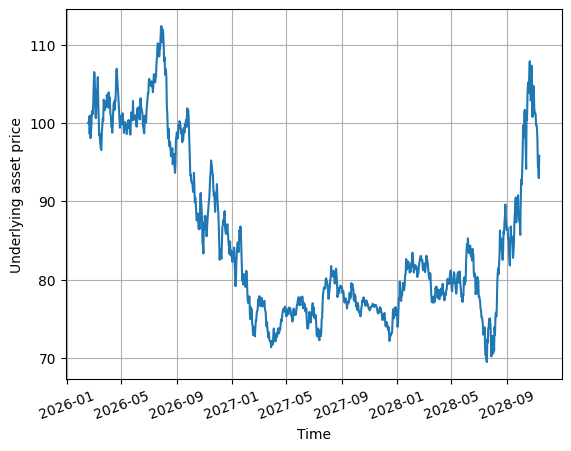

In [3]:
# S_t
dates = [pd.to_datetime(date) for date in dates]
plt.plot(dates, s_path)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Underlying asset price")
plt.xticks(rotation = 20);


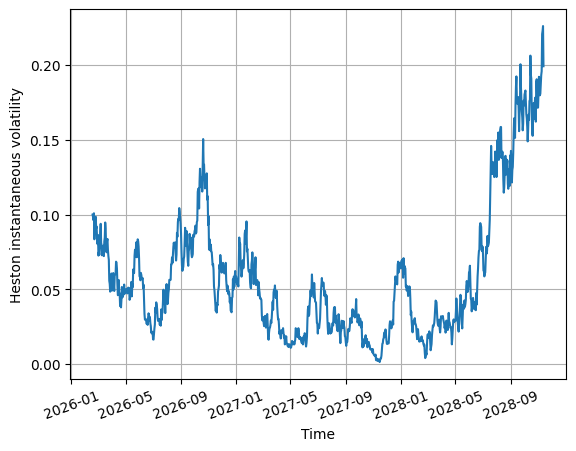

In [4]:
# v_t
plt.plot(dates, v_path)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Heston instantaneous volatility")
plt.xticks(rotation = 20);

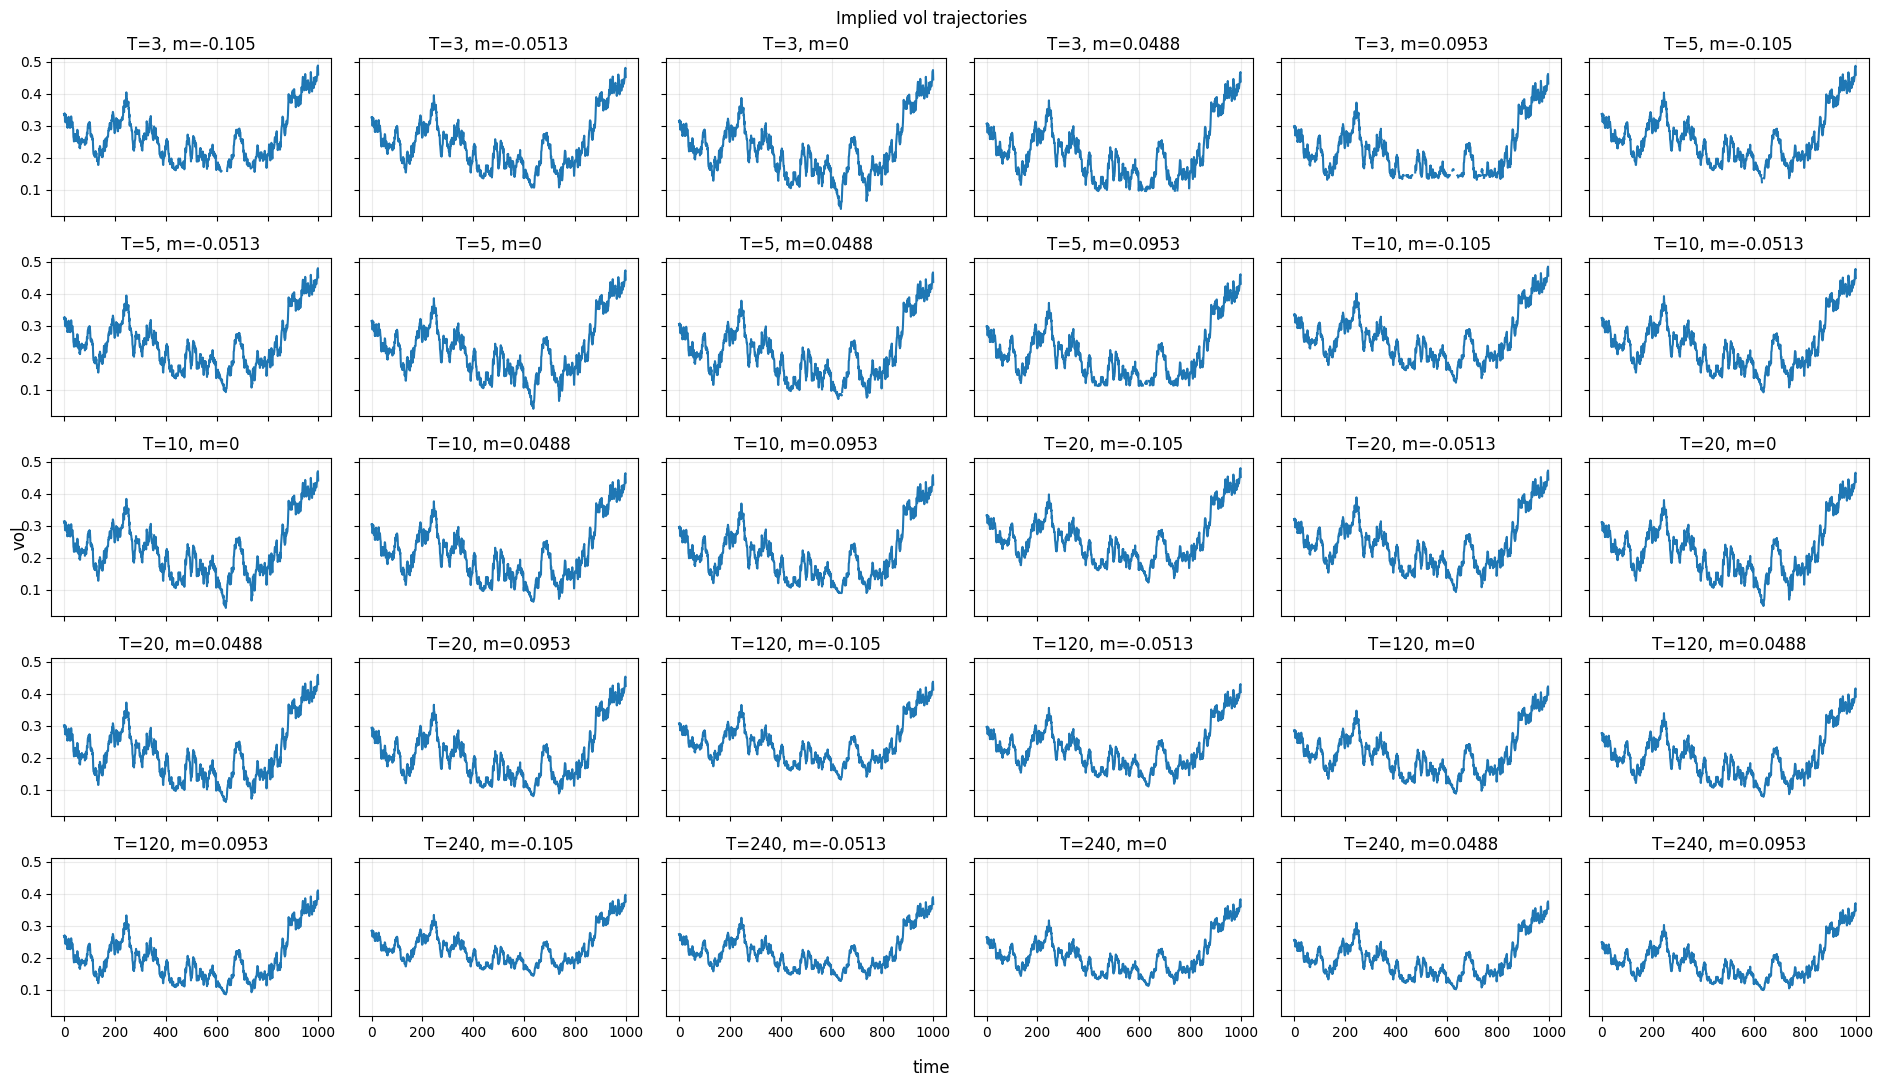

[<Figure size 1920x1100 with 30 Axes>]

In [ ]:
# volatility grid over time
from plot_utils import plot_vol_trajectories_grid

maturities = [3, 5, 10, 20, 120, 240]
log_mon = np.log(np.array([0.9, 0.95, 1, 1.05, 1.1]))

plot_vol_trajectories_grid(
    iv_cuve,
    t=np.arange(len(dates)),
    tenors=maturities,
    log_moneyness=log_mon,
    stride_tenor=1,
    stride_m=1,
    max_panels=100,
)

In [7]:
maturities = np.array([3, 5, 10, 20, 120, 240])
imputer = LinearImputer(maturities)
iv_new = imputer.impute(iv_cuve)

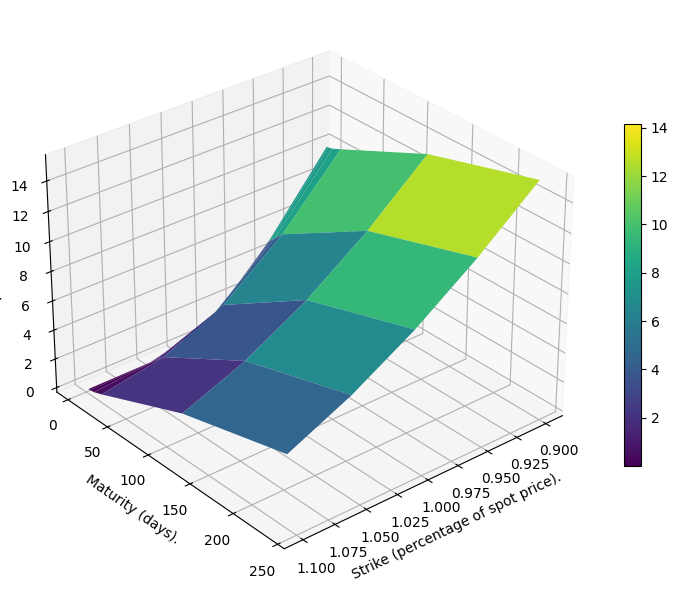

In [ ]:
# option surface on particular date

k = 2 # date
Z = np.asarray(price_cube[k])

M_labels = [3, 5, 10, 20, 120, 240]
K_labels = [0.9, 0.95, 1, 1.05, 1.1]
X, Y = np.meshgrid(K_labels, M_labels)

vmin, vmax = np.nanquantile(Z, [0.02, 0.98])
norm = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True, norm=norm, cmap="viridis")
mappable = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
mappable.set_array([])  
ax.view_init(elev=30, azim=50)

fig.colorbar(mappable, ax=ax, shrink=0.6)

ax.set_xlabel("Strike (percentage of spot price).")
ax.set_ylabel("Maturity (days).")
ax.set_zlabel("Option Value")
plt.tight_layout()
plt.show()

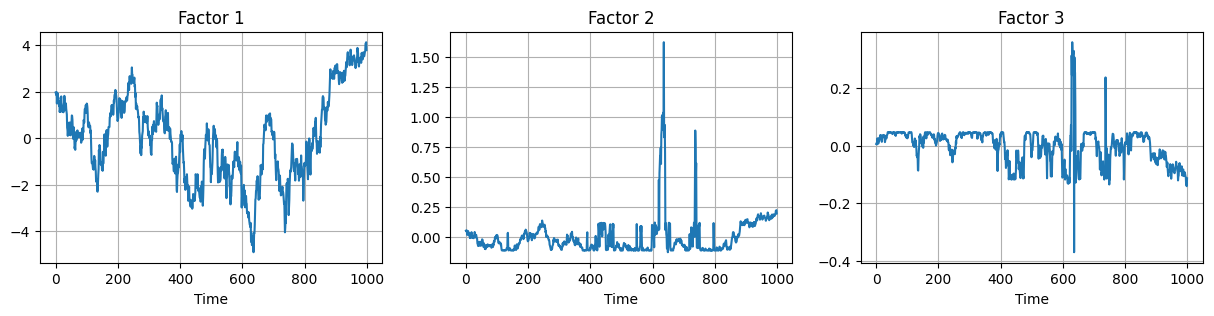

In [ ]:
# applying model and visualizing factors
# btw, factor 1 resembles v_t 
nfactors = 3
iv_pca = IvPCA(nfactors)
factors = iv_pca.fit_transform(iv_new)


fig, ax = plt.subplots(1,nfactors, figsize = (5*nfactors, 3))
for i in range(nfactors):
    ax[i].plot(factors[:,i])
    ax[i].set_title(f"Factor {i+1}")
    ax[i].grid(True)
    ax[i].set_xlabel("Time")


In [ ]:
# let's calculate approximation error
iv_inverse = iv_pca.inverse_transform(factors, )

# error in percentage of Frobenius norm (< 1 %)
np.linalg.norm(iv_new - iv_inverse) / np.linalg.norm(iv_new) * 100

np.float64(0.7802136719619193)

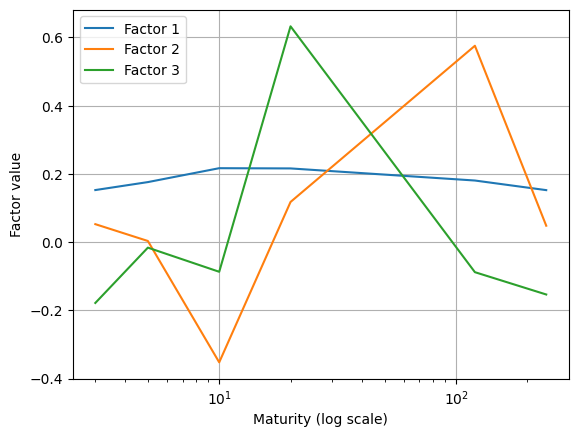

In [20]:
# as X @ V = U Sigma we want to see weights

V = iv_pca.pca.components_.T

for i in range(nfactors):
    plt.plot(maturities, V[:6, i], label = f"Factor {i+1}")
    plt.legend()
    plt.grid()
    plt.xlabel("Maturity (log scale)")
    plt.ylabel("Factor value")
    plt.xscale("log")

Interpretation follow classical ZCB curve decomposition:
- factor 1 represents level
- factor 2 -- skew
- factor 3 -- curvature

Here, however, factor 2 and 3 are very close to each other because Heston model has only one source of noise driving volatility curve. 

In [ ]:
# calibrate VAR(1,1) dynamic
var = VARDynamic(factors)
sims = var.simulate(nsteps = 300, nsim = 1000)

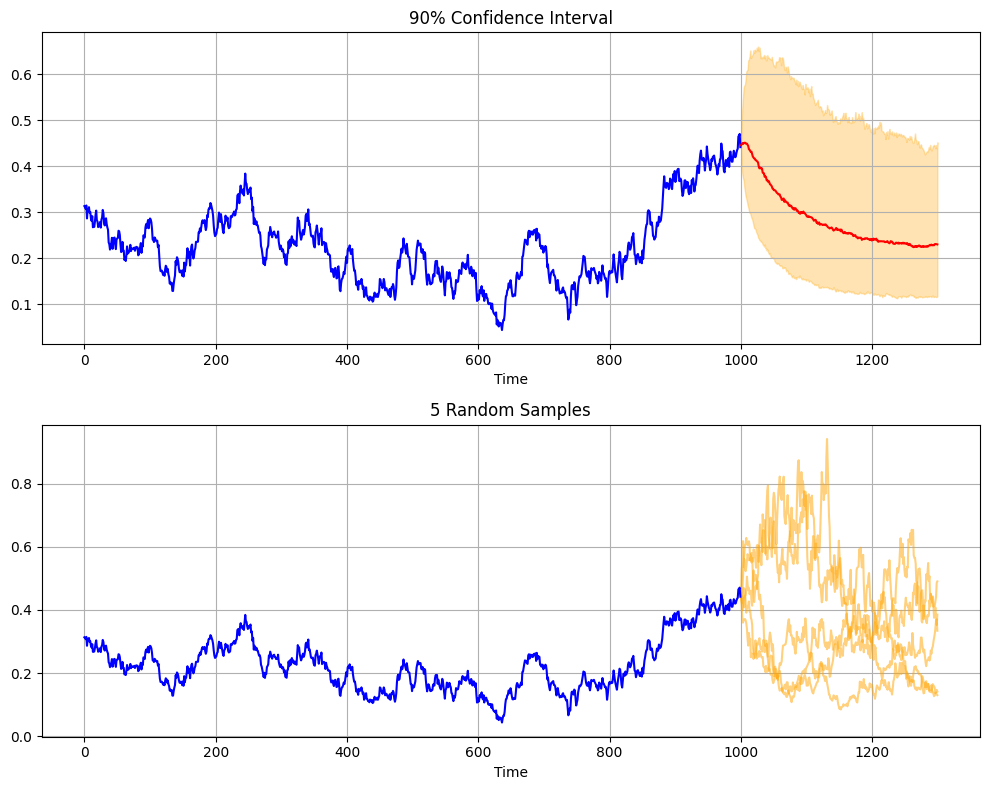

In [21]:
iv_sims = iv_pca.inverse_transform(sims)

M=2
K=2
T=iv_new.shape[0]
nsteps = iv_sims.shape[1]

t_full = np.arange(T+nsteps)
t_history = np.arange(T)
t_sims = np.arange(T,T+nsteps)

ts_hist = iv_new[:, M, K]
ts_sims = iv_sims[:,:, M,K]
upper_quantile = np.quantile(ts_sims, q = 0.95, axis = 0)
lower_quantile = np.quantile(ts_sims, q = 0.05, axis = 0)
median = np.quantile(ts_sims, q = 0.5, axis=0)

fig, ax = plt.subplots(2,1, figsize = (10,8))

ax[0].plot(t_history, ts_hist, color = "blue")
ax[0].fill_between(t_sims, upper_quantile, lower_quantile, color = "orange", alpha = 0.3)
ax[0].plot(t_sims, median, color = "red")
ax[0].grid(True)
ax[0].set_title("90% Confidence Interval")
ax[0].set_xlabel("Time")


nsamples = 5

idx = np.random.choice(np.arange(iv_sims.shape[0]), nsamples)
ax[1].plot(t_sims, iv_sims[idx, :, M, K].T, color = "orange", alpha = 0.5)
ax[1].plot(t_history, ts_hist, color = "blue");
ax[1].grid(True)
ax[1].set_title("5 Random Samples")
ax[1].set_xlabel("Time")
plt.tight_layout()


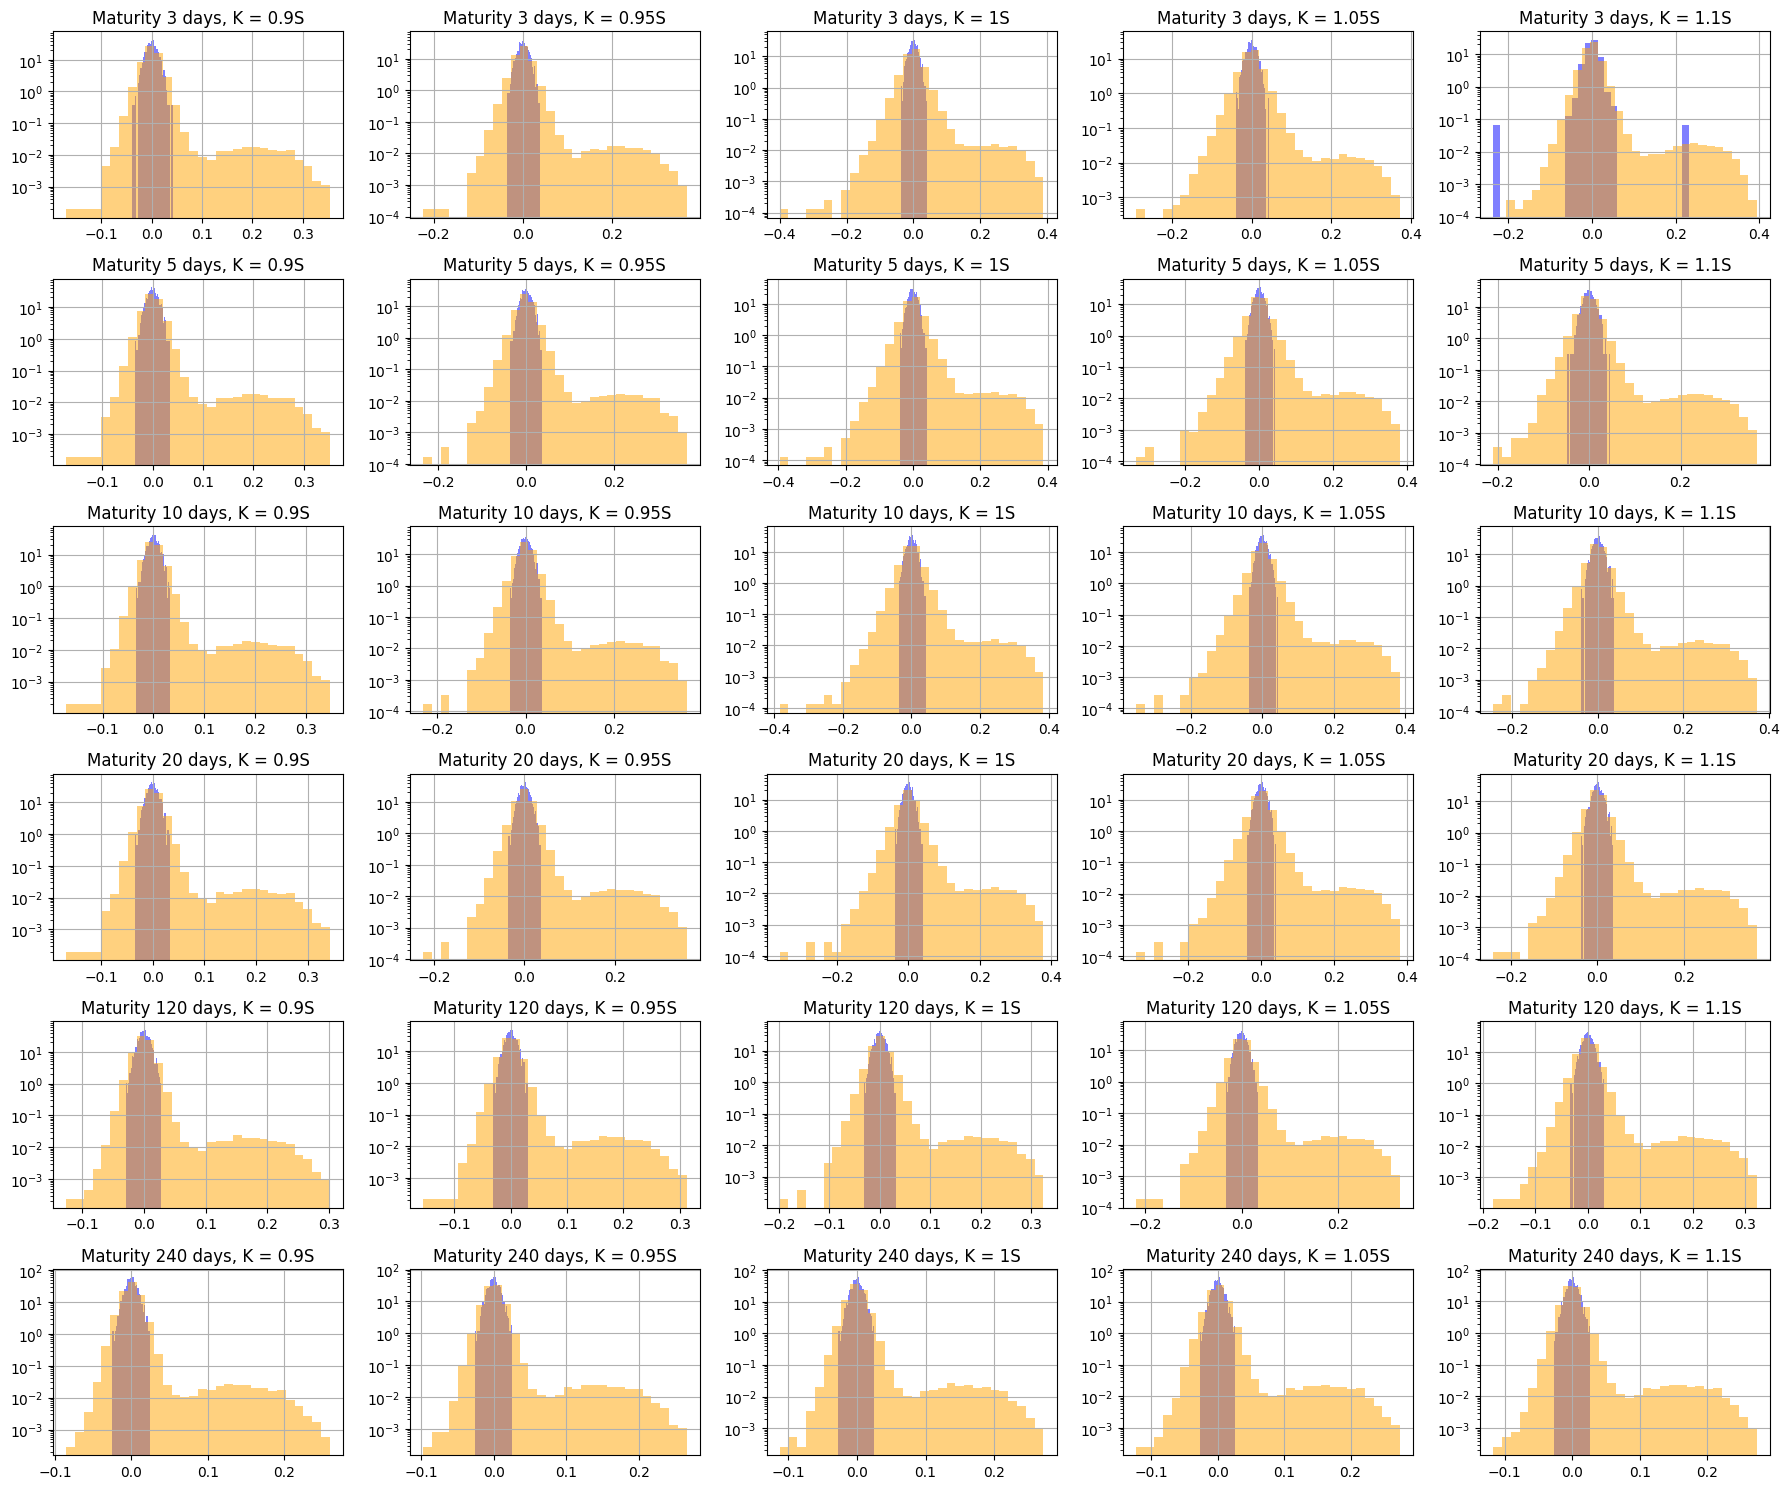

In [22]:
from plot_utils import plot_hist_grid

M_labels = [3, 5, 10, 20, 120, 240]
K_labels = [0.9, 0.95, 1, 1.05, 1.1]

plot_hist_grid(M_labels, K_labels, iv_new, iv_sims)

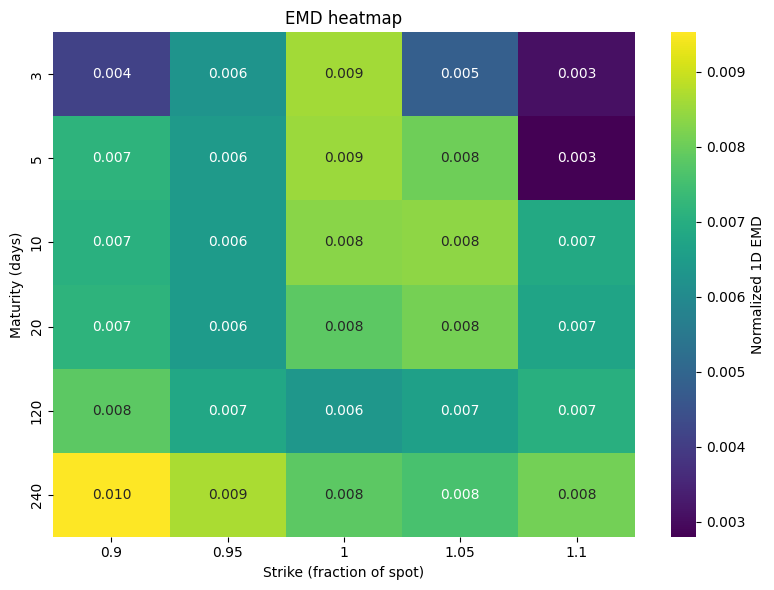

Mean EMD: 0.006984
0.0044453735246425975


In [25]:
from metrics import EMD_Surface, MMD, visualize_acf_panels

emd = EMD_Surface(iv_new)
emd_matrix, emd_mean = emd.compute(iv_sims)
emd.visualize(iv_sims, M_labels, K_labels)
print(emd.compute_sliced(iv_sims))

  0%|                                                                                            | 0/10 [00:00<?, ?it/s]



















  0%|                                                                                            | 0/10 [24:54<?, ?it/s]


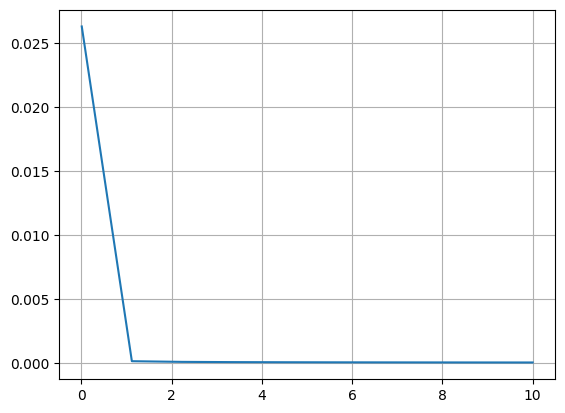

In [33]:
from tqdm import tqdm

deltas = np.linspace(0.01, 10, 10)
mmd_score = [MMD(iv_new, delta=delta).compute_mmd(iv_sims[:100, ...]) for delta in tqdm(deltas)]

plt.plot(deltas, mmd_score)
plt.grid(True);

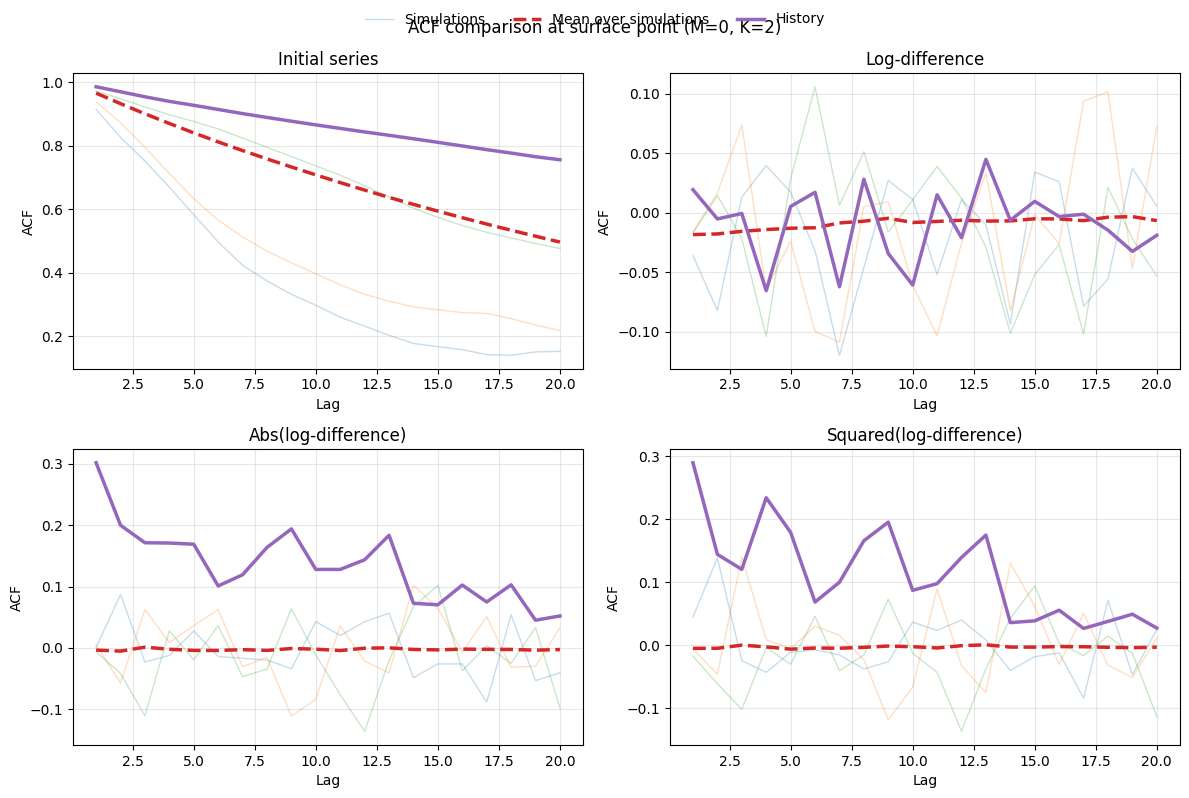

In [34]:
visualize_acf_panels(
    iv_new,
    iv_sims,
    m_idx=0,
    k_idx=2,
    nlags=20,
    nsamples=3,
    drop_lag0=True
)

__Results__
So, EMD and MMD are really small and close to zero -- we simulate increments quite well. But ACFs of absolute and squarred increments does not really align with real data, therefore advanced models are needed.